# 08 — Calibration Sensitivity

**Goal**: quantify how mic-to-mic gain and phase mismatch degrades beamformer
performance, and how well calibration correction restores it.

The Infineon IM69D120 MEMS microphone specifies:
- Sensitivity tolerance: **±1 dB** (gain mismatch)
- Phase tolerance: **±2°** at 1 kHz

Mismatch model: each mic n receives a complex gain error
`e_n = g_n · exp(j·φ_n)` where `g_n ~ Uniform(−G, +G)` dB and
`φ_n ~ Uniform(−Φ, +Φ)` degrees.  Applied to the snapshot vector
before CSM accumulation.

Key questions:
1. Does IM69D120-spec mismatch materially degrade DoA accuracy?
2. Which algorithm is most sensitive?
3. How much mismatch can each algorithm tolerate?
4. Does perfect calibration fully restore performance?
5. How much residual calibration error can we tolerate?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MIN  = 0.025
R_MAX  = 0.150
FS     = 48_000
FREQ   = 4000.0
SNR_DB = 20.0
N_SNAP = 512   # well above CSM convergence — isolates mismatch effect


In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)
N_MICS = len(x_arr)
print(f'N_MICS = {N_MICS}')


N_MICS = 96


In [3]:
def steering_vector(x, y, az_deg, freq):
    u = np.sin(np.radians(az_deg))
    return np.exp(1j * 2 * np.pi * freq / C * u * x) / np.sqrt(len(x))


def steering_matrix(x, y, az_grid, freq):
    u = np.sin(np.radians(az_grid))
    phase = 2 * np.pi * freq / C * np.outer(x, u)
    return np.exp(1j * phase) / np.sqrt(len(x))


def make_mismatch(N, gain_db_max, phase_deg_max, rng):
    """Complex gain error per mic: magnitude from gain_db_max, phase from phase_deg_max."""
    gain_db = rng.uniform(-gain_db_max, gain_db_max, N)
    phi     = np.radians(rng.uniform(-phase_deg_max, phase_deg_max, N))
    return 10 ** (gain_db / 20) * np.exp(1j * phi)


def make_csm(x, y, sources, freq, snr_db, n_snap, mismatch=None, seed=None):
    local_rng = np.random.default_rng(seed)
    N = len(x)
    e = mismatch if mismatch is not None else np.ones(N, dtype=complex)
    max_power = max(p for _, p in sources)
    noise_var = max_power / (10 ** (snr_db / 10))
    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for az, power in sources:
            h = steering_vector(x, y, az, freq)
            s = local_rng.standard_normal() + 1j * local_rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        noise = local_rng.standard_normal(N) + 1j * local_rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        y_snap = e * y_snap
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap


def calibrate_csm(R, mismatch):
    """Correct CSM for known complex gain errors: R_corr = diag(1/e) R diag(1/e*)."""
    e_inv = 1.0 / mismatch
    return np.outer(e_inv, e_inv.conj()) * R


def beamform_ds(x, y, R, freq, az_grid):
    H = steering_matrix(x, y, az_grid, freq)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    N = R.shape[0]
    R_loaded = R + diag_load * np.trace(R) / N * np.eye(N)
    R_inv = inv(R_loaded)
    H = steering_matrix(x, y, az_grid, freq)
    denom = np.real(np.sum(H.conj() * (R_inv @ H), axis=0))
    return 1.0 / np.maximum(denom, 1e-300)


def beamform_music(x, y, R, freq, az_grid, n_sources=1):
    _, eigvecs = np.linalg.eigh(R)
    E_n = eigvecs[:, :R.shape[0] - n_sources]
    En_proj = E_n @ E_n.conj().T
    H = steering_matrix(x, y, az_grid, freq)
    denom = np.real(np.sum(H.conj() * (En_proj @ H), axis=0))
    return 1.0 / np.maximum(denom, 1e-300)


az_grid  = np.linspace(-60, 60, 1201)
src_one  = [(25.0, 1.0)]
src_two  = [(-15.0, 1.0), (15.0, 1.0)]
colors   = {'D&S': 'steelblue', 'MVDR': 'darkorange', 'MUSIC': 'forestgreen'}


## 1 — DoA Error vs Mismatch Severity

Single source at 25°, SNR=20 dB, N_SNAP=512.
For each mismatch level, draw N_TRIALS independent mismatch vectors
(different random gain/phase per mic), compute CSM, measure peak DoA.
Mismatch levels expressed as `(gain_db_max, phase_deg_max)`.
The IM69D120 spec point (1 dB, 2°) is marked.


In [4]:
# Sweep: gain_db_max from 0 to 4; phase_deg_max = 2 * gain_db_max
GAIN_STEPS  = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
PHASE_STEPS = [g * 2 for g in GAIN_STEPS]   # keep ratio from IM69D120 spec
N_TRIALS    = 30

results = {alg: {'mean': [], 'std': []} for alg in ['D&S', 'MVDR', 'MUSIC']}

for gain_db, phase_deg in zip(GAIN_STEPS, PHASE_STEPS):
    errs = {'D&S': [], 'MVDR': [], 'MUSIC': []}
    for trial in range(N_TRIALS):
        mismatch_rng = np.random.default_rng(trial * 100)
        e = make_mismatch(N_MICS, gain_db, phase_deg, mismatch_rng)
        R = make_csm(x_arr, y_arr, src_one, FREQ, SNR_DB, N_SNAP,
                     mismatch=e, seed=trial)
        for alg, fn, kw in [
            ('D&S',   beamform_ds,    {}),
            ('MVDR',  beamform_mvdr,  {}),
            ('MUSIC', beamform_music, {'n_sources': 1}),
        ]:
            m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            errs[alg].append(abs(az_grid[np.argmax(m)] - 25.0))
    for alg in results:
        results[alg]['mean'].append(np.mean(errs[alg]))
        results[alg]['std'].append(np.std(errs[alg]))

print('Mismatch sweep complete')
for alg in ['D&S', 'MVDR', 'MUSIC']:
    print(f'  {alg}: mean DoA error at IM69D120 spec (1dB, 2°) = '
          f'{results[alg]["mean"][2]:.3f}° ± {results[alg]["std"][2]:.3f}°')


Mismatch sweep complete
  D&S: mean DoA error at IM69D120 spec (1dB, 2°) = 0.030° ± 0.046°
  MVDR: mean DoA error at IM69D120 spec (1dB, 2°) = 0.027° ± 0.044°
  MUSIC: mean DoA error at IM69D120 spec (1dB, 2°) = 0.030° ± 0.046°


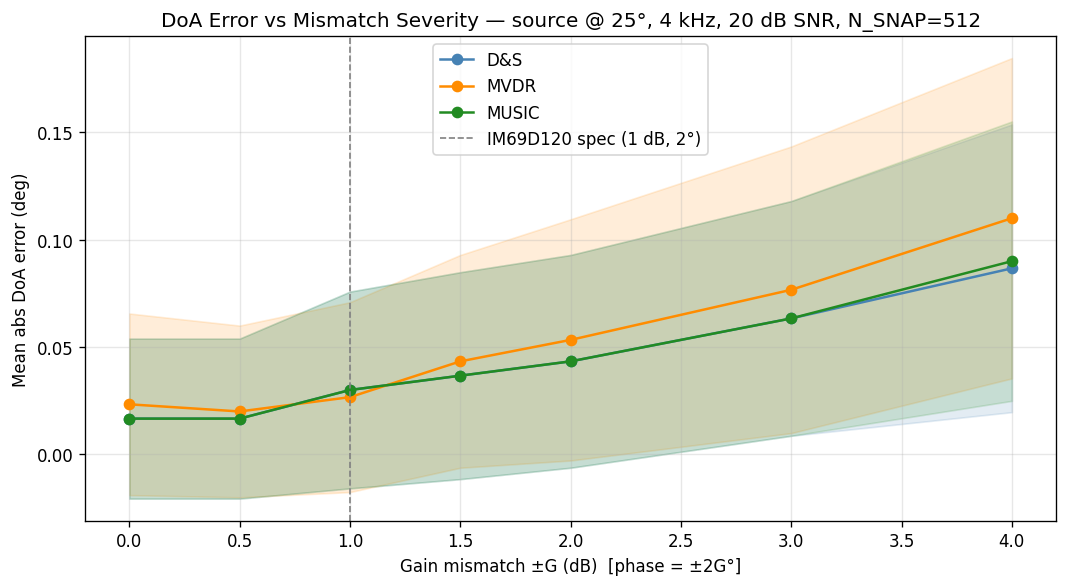

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

for alg in ['D&S', 'MVDR', 'MUSIC']:
    mean = np.array(results[alg]['mean'])
    std  = np.array(results[alg]['std'])
    ax.plot(GAIN_STEPS, mean, 'o-', color=colors[alg], label=alg, linewidth=1.5)
    ax.fill_between(GAIN_STEPS, mean - std, mean + std,
                    color=colors[alg], alpha=0.15)

ax.axvline(1.0, color='gray', linestyle='--', linewidth=1,
           label='IM69D120 spec (1 dB, 2°)')
ax.set_xlabel('Gain mismatch ±G (dB)  [phase = ±2G°]')
ax.set_ylabel('Mean abs DoA error (deg)')
ax.set_title(f'DoA Error vs Mismatch Severity — source @ 25°, '
             f'{FREQ/1000:.0f} kHz, {SNR_DB:.0f} dB SNR, N_SNAP={N_SNAP}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cal_doa_vs_mismatch.png', dpi=150, bbox_inches='tight')
plt.show()


## 2 — Gain vs Phase: Which Matters More?

Separate the gain and phase contributions at the IM69D120 spec level.
Run the same sweep with only gain mismatch, only phase mismatch, and combined.


In [6]:
IM_GAIN  = 1.0   # dB
IM_PHASE = 2.0   # deg

conditions = [
    ('No mismatch',        0.0,     0.0),
    ('Gain only (±1dB)',   IM_GAIN, 0.0),
    ('Phase only (±2°)',   0.0,     IM_PHASE),
    ('Combined (spec)',    IM_GAIN, IM_PHASE),
]

rows = []
for label, gdb, pdeg in conditions:
    for alg, fn, kw in [
        ('D&S',   beamform_ds,    {}),
        ('MVDR',  beamform_mvdr,  {}),
        ('MUSIC', beamform_music, {'n_sources': 1}),
    ]:
        errs = []
        for trial in range(N_TRIALS):
            mismatch_rng = np.random.default_rng(trial * 100)
            e = make_mismatch(N_MICS, gdb, pdeg, mismatch_rng)
            R = make_csm(x_arr, y_arr, src_one, FREQ, SNR_DB, N_SNAP,
                         mismatch=e, seed=trial)
            m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            errs.append(abs(az_grid[np.argmax(m)] - 25.0))
        rows.append({
            'Condition': label,
            'Algorithm': alg,
            'Mean error (°)': round(np.mean(errs), 3),
            'Std (°)': round(np.std(errs), 3),
        })

df = pd.DataFrame(rows)
pivot = df.pivot(index='Condition', columns='Algorithm', values='Mean error (°)')
# maintain meaningful row order
pivot = pivot.reindex([c[0] for c in conditions])
print(pivot.to_string())


Algorithm           D&S  MUSIC   MVDR
Condition                            
No mismatch       0.017  0.017  0.023
Gain only (±1dB)  0.017  0.017  0.030
Phase only (±2°)  0.027  0.027  0.027
Combined (spec)   0.030  0.030  0.027


## 3 — Resolution Reliability Under IM69D120 Mismatch

Two sources at ±15°, 4 kHz, 20 dB SNR, N_SNAP=256.
Compare no-mismatch vs IM69D120-spec mismatch (1 dB, 2°).
Resolution criterion: −6 dB valley between the two peaks.


In [7]:
N_SNAP_RES = 256
N_TRIALS_R = 30


def is_resolved(az_grid, beam_map, az1=-15.0, az2=15.0, threshold_db=-6):
    i1 = np.argmin(np.abs(az_grid - az1))
    i2 = np.argmin(np.abs(az_grid - az2))
    lo, hi = min(i1, i2), max(i1, i2)
    valley = beam_map[lo:hi+1].min()
    return 10 * np.log10(valley / beam_map.max()) < threshold_db


rows_res = []
for label, gdb, pdeg in [('No mismatch', 0.0, 0.0),
                          ('IM69D120 spec (1dB, 2°)', IM_GAIN, IM_PHASE)]:
    for alg, fn, kw in [
        ('D&S',   beamform_ds,    {}),
        ('MVDR',  beamform_mvdr,  {}),
        ('MUSIC', beamform_music, {'n_sources': 2}),
    ]:
        resolved = 0
        for trial in range(N_TRIALS_R):
            mismatch_rng = np.random.default_rng(trial * 200)
            e = make_mismatch(N_MICS, gdb, pdeg, mismatch_rng)
            R = make_csm(x_arr, y_arr, src_two, FREQ, SNR_DB, N_SNAP_RES,
                         mismatch=e, seed=trial + 500)
            m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            if is_resolved(az_grid, m):
                resolved += 1
        rows_res.append({
            'Condition': label, 'Algorithm': alg,
            'Resolution rate': round(resolved / N_TRIALS_R, 2),
        })

df_res = pd.DataFrame(rows_res)
pivot_res = df_res.pivot(index='Condition', columns='Algorithm', values='Resolution rate')
pivot_res = pivot_res.reindex(['No mismatch', 'IM69D120 spec (1dB, 2°)'])
print(pivot_res.to_string())


Algorithm                D&S  MUSIC  MVDR
Condition                                
No mismatch              0.0    1.0   1.0
IM69D120 spec (1dB, 2°)  0.0    1.0   1.0


## 4 — Calibration Correction

Apply `R_corr = diag(1/e) · R_mismatch · diag(1/e*)` to undo the mismatch.
Four conditions compared:
1. No mismatch (ideal baseline)
2. IM69D120 mismatch, uncorrected
3. Perfect calibration (correction = true e)
4. Imperfect calibration (residual ±0.2 dB, ±0.5°)


In [8]:
N_TRIALS_CAL = 30
CAL_RESIDUAL_GAIN  = 0.2   # dB — post-calibration residual
CAL_RESIDUAL_PHASE = 0.5   # deg

rows_cal = []
for alg, fn, kw in [
    ('D&S',   beamform_ds,    {}),
    ('MVDR',  beamform_mvdr,  {}),
    ('MUSIC', beamform_music, {'n_sources': 1}),
]:
    errs = {'No mismatch': [], 'Uncorrected': [], 'Perfect cal': [], 'Imperfect cal': []}
    for trial in range(N_TRIALS_CAL):
        rng_m = np.random.default_rng(trial * 300)
        e_true = make_mismatch(N_MICS, IM_GAIN, IM_PHASE, rng_m)

        # residual error in the calibration estimate
        rng_r = np.random.default_rng(trial * 300 + 1)
        e_residual = make_mismatch(N_MICS, CAL_RESIDUAL_GAIN, CAL_RESIDUAL_PHASE, rng_r)
        e_estimated = e_true * e_residual

        R_ideal = make_csm(x_arr, y_arr, src_one, FREQ, SNR_DB, N_SNAP,
                           mismatch=None, seed=trial)
        R_mis   = make_csm(x_arr, y_arr, src_one, FREQ, SNR_DB, N_SNAP,
                           mismatch=e_true, seed=trial)
        R_pcal  = calibrate_csm(R_mis, e_true)
        R_ical  = calibrate_csm(R_mis, e_estimated)

        for label, R in [('No mismatch', R_ideal), ('Uncorrected', R_mis),
                          ('Perfect cal', R_pcal), ('Imperfect cal', R_ical)]:
            m = fn(x_arr, y_arr, R, FREQ, az_grid, **kw)
            errs[label].append(abs(az_grid[np.argmax(m)] - 25.0))

    for label in errs:
        rows_cal.append({
            'Algorithm': alg,
            'Condition': label,
            'Mean error (°)': round(np.mean(errs[label]), 3),
            'Std (°)': round(np.std(errs[label]), 3),
        })

df_cal = pd.DataFrame(rows_cal)
pivot_cal = df_cal.pivot(index='Condition', columns='Algorithm', values='Mean error (°)')
pivot_cal = pivot_cal.reindex(['No mismatch', 'Uncorrected', 'Perfect cal', 'Imperfect cal'])
print('Mean DoA error (°) by condition and algorithm:')
print(pivot_cal.to_string())


Mean DoA error (°) by condition and algorithm:
Algorithm        D&S  MUSIC   MVDR
Condition                         
No mismatch    0.017  0.017  0.023
Uncorrected    0.023  0.027  0.023
Perfect cal    0.017  0.017  0.023
Imperfect cal  0.017  0.017  0.023


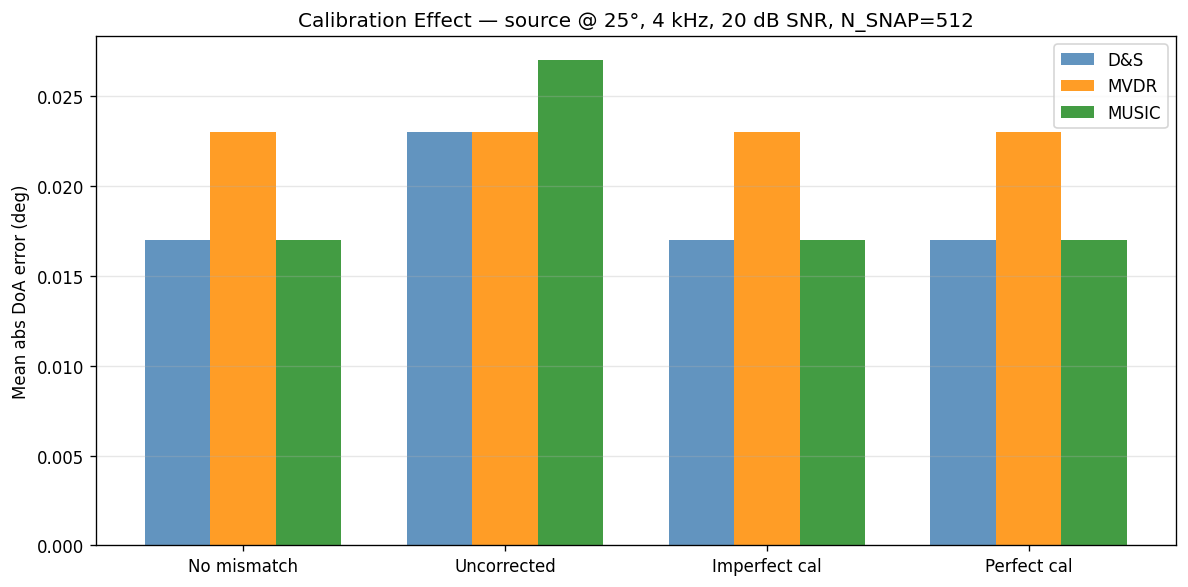

In [9]:
cond_order = ['No mismatch', 'Uncorrected', 'Imperfect cal', 'Perfect cal']
algs_plot  = ['D&S', 'MVDR', 'MUSIC']
x_pos      = np.arange(len(cond_order))
width      = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, alg in enumerate(algs_plot):
    vals = [pivot_cal.loc[c, alg] for c in cond_order]
    ax.bar(x_pos + i * width, vals, width, label=alg, color=list(colors.values())[i],
           alpha=0.85)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(cond_order)
ax.set_ylabel('Mean abs DoA error (deg)')
ax.set_title(f'Calibration Effect — source @ 25°, {FREQ/1000:.0f} kHz, '
             f'{SNR_DB:.0f} dB SNR, N_SNAP={N_SNAP}')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cal_correction_effect.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary


In [10]:
print('=== DoA error at IM69D120 spec (1dB gain, 2° phase) ===')
for alg in ['D&S', 'MVDR', 'MUSIC']:
    m = results[alg]['mean'][2]  # index 2 = gain=1.0dB step
    s = results[alg]['std'][2]
    print(f'  {alg}: {m:.3f}° ± {s:.3f}°')
print()
print('=== Resolution reliability (±15° sources, N_SNAP=256) ===')
print(pivot_res.to_string())
print()
print('=== Calibration correction (DoA error, source @ 25°) ===')
print(pivot_cal.to_string())


=== DoA error at IM69D120 spec (1dB gain, 2° phase) ===
  D&S: 0.030° ± 0.046°
  MVDR: 0.027° ± 0.044°
  MUSIC: 0.030° ± 0.046°

=== Resolution reliability (±15° sources, N_SNAP=256) ===
Algorithm                D&S  MUSIC  MVDR
Condition                                
No mismatch              0.0    1.0   1.0
IM69D120 spec (1dB, 2°)  0.0    1.0   1.0

=== Calibration correction (DoA error, source @ 25°) ===
Algorithm        D&S  MUSIC   MVDR
Condition                         
No mismatch    0.017  0.017  0.023
Uncorrected    0.023  0.027  0.023
Perfect cal    0.017  0.017  0.023
Imperfect cal  0.017  0.017  0.023
